# LECTURE 5
**Topic:** Sampling of Continuous-Time Sinusoids  
**Textbook References:** Section 1.6

---

## Key Points

- Sampling $x(t)=\cos(\Omega t+\phi)$ at rate $f_s=1/T_s$ gives $x[n]=\cos(\omega n+\phi)$ where $\omega=\Omega T_s$.
- $\omega = \Omega T_s = 2\pi f/f_s = 2\pi T_s/T$
- At high sampling rates, samples closely track the continuous-time signal.
- Two rates $f_s$ and $f_s'$ produce samples with the same effective $\omega$ when $T_s \pm T_s' = k T$ for integer $k$.


---
## Theory and Examples

### 1. The Sampling Formula

$$x[n] = x(nT_s) = \cos(\Omega \cdot nT_s + \phi) = \cos(\omega n + \phi)$$

where $\omega = \Omega T_s$. The sampling period is $T_s$ and sampling rate is $f_s = 1/T_s$ (samples/sec).

### 2. Example: Two Sampling Rates

$x(t) = \cos\left(\frac{400\pi}{3}t - \frac{\pi}{8}\right)$

- $x_1[n] = \cos\left(\frac{2\pi}{5}n - \frac{\pi}{8}\right)$: $T_s = 3.0\text{ ms}$
- $x_2[n] = \cos\left(\frac{2\pi}{3}n - \frac{\pi}{8}\right)$: $T_s = 5.0\text{ ms}$


x(t) = cos(133.33*pi*t + -0.125*pi)
f = 66.6667 Hz,  T = 15.0000 ms

Rate 1: Ts=3.0 ms, omega1=Omega*Ts1=1.2566 rad = 2pi/5=1.2566
Rate 2: Ts=5.0 ms, omega2=Omega*Ts2=2.0944 rad = 2pi/3=2.0944


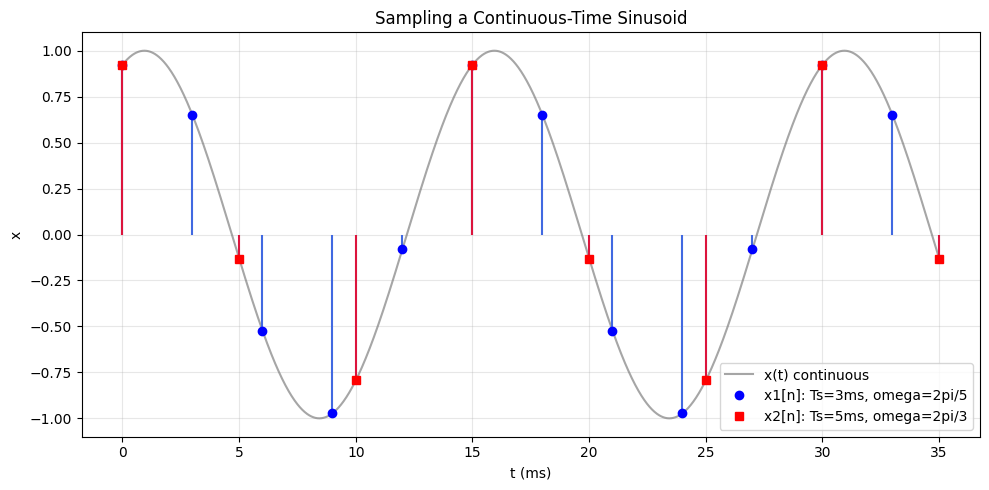

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Continuous-time sinusoid parameters
Omega = 400*np.pi/3   # rad/s
phi   = -np.pi/8
f     = Omega/(2*np.pi)
T     = 1/f
print(f'x(t) = cos({Omega/np.pi:.2f}*pi*t + {phi/np.pi:.3f}*pi)')
print(f'f = {f:.4f} Hz,  T = {T*1000:.4f} ms')
print()

# Sampling rates
Ts1 = 3.0e-3;  omega1 = Omega * Ts1
Ts2 = 5.0e-3;  omega2 = Omega * Ts2
print(f'Rate 1: Ts={Ts1*1000} ms, omega1=Omega*Ts1={omega1:.4f} rad = 2pi/5={2*np.pi/5:.4f}')
print(f'Rate 2: Ts={Ts2*1000} ms, omega2=Omega*Ts2={omega2:.4f} rad = 2pi/3={2*np.pi/3:.4f}')

# Plot
t = np.linspace(0, 0.035, 2000)
x_ct = np.cos(Omega*t + phi)

n1 = np.arange(0, 12); t1 = n1 * Ts1; x1 = np.cos(omega1*n1 + phi)
n2 = np.arange(0, 8);  t2 = n2 * Ts2; x2 = np.cos(omega2*n2 + phi)

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(t*1000, x_ct, 'gray', lw=1.5, alpha=0.7, label='x(t) continuous')
markerline, stemlines, baseline = ax.stem(t1*1000, x1, linefmt='royalblue', markerfmt='bo', basefmt=' ')
markerline.set_label(f'x1[n]: Ts=3ms, omega=2pi/5'); 
markerline2, stemlines2, baseline2 = ax.stem(t2*1000, x2, linefmt='crimson', markerfmt='rs', basefmt=' ')
markerline2.set_label(f'x2[n]: Ts=5ms, omega=2pi/3')
ax.set_xlabel('t (ms)'); ax.set_ylabel('x'); ax.set_title('Sampling a Continuous-Time Sinusoid')
ax.legend(); ax.grid(True,alpha=0.3)
plt.tight_layout(); plt.show()

---
### 3. Relationship Between Sampling Rate and Periodicity

The discrete-time sinusoid $x[n]=\cos(\omega n+\phi)$ with $\omega=\Omega T_s = 2\pi T_s/T$ is periodic iff:
$$\omega = \frac{k}{N}\cdot 2\pi \iff \frac{T_s}{T} = \frac{k}{N} \iff \frac{f_s}{f} = \frac{N}{k}$$

i.e., **$f_s/f$ is a rational number**.

Special cases:
- **$x[n]$ is constant:** $T_s/T = $ integer, i.e., $f_s = f/k$
- **$x[n]$ alternates $a, -a, a, -a, \ldots$:** $\omega = \pi$ i.e., $T_s = T/2$

### 4. Effect of Sampling Rate on Signal Appearance

If $T_s/T$ is small (high sampling rate $f_s \gg f$), samples closely track $x(t)$.  
The samples can be used to reconstruct the continuous-time signal by interpolation.

### 5. Multiple Sampling Rates Giving Same Frequency

$\omega$ and $\omega + 2k\pi$ describe the same DT sinusoid. Two sampling rates $T_s$ and $T_s'$ produce the same $\omega$ when:
$$T_s \pm T_s' = k T \quad \text{for some integer } k$$


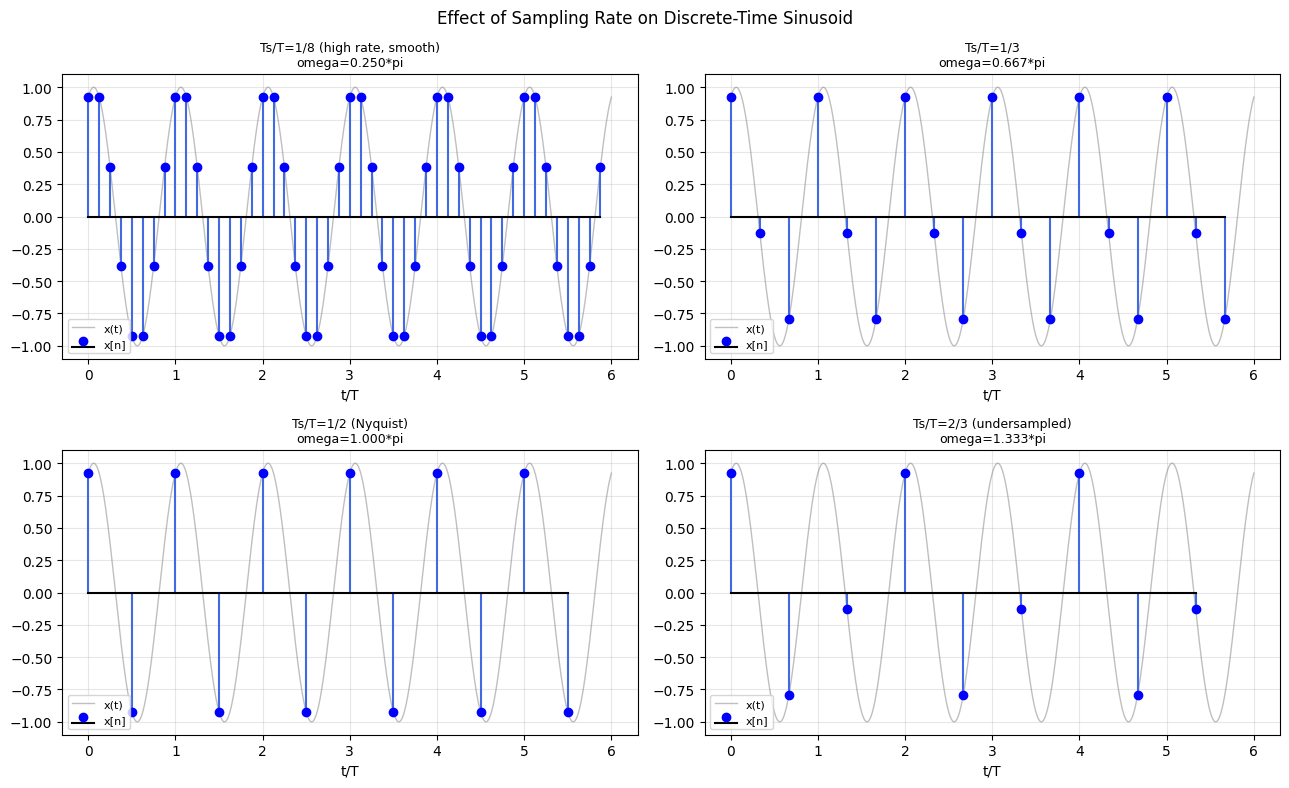

=== Multiple Ts giving the same x1[n] (omega=2pi/5) ===
Base Ts: omega/Omega = 3.0000 ms
  k=1: Ts=18.00ms, omega=7.5398rad, reduced=1.2566rad (0.400*pi)
  k=2: Ts=33.00ms, omega=13.8230rad, reduced=1.2566rad (0.400*pi)
  k=3: Ts=48.00ms, omega=20.1062rad, reduced=1.2566rad (0.400*pi)
  k=4: Ts=63.00ms, omega=26.3894rad, reduced=1.2566rad (0.400*pi)


In [2]:
# Demonstrate effect of sampling rate
Omega = 400*np.pi/3; phi = -np.pi/8
T = 2*np.pi/Omega

fig, axes = plt.subplots(2, 2, figsize=(13, 8))
t = np.linspace(0, 6*T, 1000)
x_ct = np.cos(Omega*t + phi)

sampling_fracs = [1/8, 1/3, 1/2, 2/3]  # Ts/T
titles = ['Ts/T=1/8 (high rate, smooth)', 'Ts/T=1/3', 'Ts/T=1/2 (Nyquist)', 'Ts/T=2/3 (undersampled)']

for ax, frac, title in zip(axes.flat, sampling_fracs, titles):
    Ts = frac * T
    omega = Omega * Ts
    n_max = int(6*T/Ts)
    n = np.arange(n_max)
    tn = n * Ts
    xn = np.cos(omega*n + phi)
    ax.plot(t/T, x_ct, 'gray', lw=1, alpha=0.5, label='x(t)')
    ax.stem(tn/T, xn, linefmt='royalblue', markerfmt='bo', basefmt='k', label=f'x[n]')
    ax.set_title(f'{title}\nomega={omega/np.pi:.3f}*pi', fontsize=9)
    ax.set_xlabel('t/T'); ax.legend(fontsize=8); ax.grid(True,alpha=0.3)

plt.suptitle('Effect of Sampling Rate on Discrete-Time Sinusoid', fontsize=12)
plt.tight_layout(); plt.show()

# Multiple rates giving same omega
print('=== Multiple Ts giving the same x1[n] (omega=2pi/5) ===')
omega_target = 2*np.pi/5
Ts_base = omega_target / Omega
print(f'Base Ts: omega/Omega = {Ts_base*1000:.4f} ms')
for k in range(1,5):
    Ts_k = Ts_base + k*T
    omega_k = Omega * Ts_k
    # Reduce omega_k to [0, pi]
    omega_k_red = omega_k % (2*np.pi)
    if omega_k_red > np.pi: omega_k_red = 2*np.pi - omega_k_red
    print(f'  k={k}: Ts={Ts_k*1000:.2f}ms, omega={omega_k:.4f}rad, reduced={omega_k_red:.4f}rad ({omega_k_red/np.pi:.3f}*pi)')

---
### 6. Example: Multiple Sampling Rates

For $x(t) = \cos(400\pi t/3 - \pi/8)$: $T=15$ ms, $f=200/3$ Hz.

- Rates producing $x_1[n]=\cos(2\pi n/5 - \pi/8)$: $T_s = 3.0 + k(15.0)$ ms, $k=0,1,2,\ldots$

- Rates producing $x_3[n]=\cos(2\pi n/5 + \pi/8)$ (phase-flipped): use $\cos(-\theta)=\cos(\theta)$,
  so $x_3[n]=\cos(-2\pi n/5 - \pi/8)$, which needs $T_s' = -3 + k(15)$ ms.
  Since $T_s>0$: $T_s = 12 + k(15)$ ms, $k=1,2,\ldots$


---
## Summary

| Formula | Meaning |
|---|---|
| $\omega = \Omega T_s$ | DT frequency from CT frequency and sampling period |
| $\omega = 2\pi f/f_s$ | DT frequency from cyclic frequencies |
| $T_s \pm T_s' = kT$ | Two rates produce same effective $\omega$ |

### Mistakes to Avoid
1. Confusing $\omega$ (rad/sample) and $\Omega$ (rad/sec).
2. Assuming $\omega$ always stays in $[0,\pi]$ after computing $\Omega T_s$ — you may need to subtract multiples of $2\pi$ and/or use $\cos(-x)=\cos(x)$.
3. Forgetting the phase can flip sign when using the $\cos(-x)=\cos(x)$ identity.
